# Chapter 8 — Confidence Intervals

What a 95% interval promises, and how to build one for a mean or a proportion.

| Section | What it covers |
|---|---|
| 8.1 | What “95% confident” means |
| 8.2 | The t distribution |
| 8.3 | Intervals for proportions |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [Confidence Intervals](https://khh-aka-lucifer.github.io/statLab/chapters/confidence-intervals/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## From a point to a range

A sample mean is a single number and it is essentially always wrong. A **confidence interval**
replaces it with a range, built so that the procedure captures the truth a stated share of the time.

Read that sentence again, because the promise is about the procedure, not about any one interval.
That distinction is the whole of section 8.1.

In [2]:
penguins = pd.read_csv(DATA / "penguins.csv")
pop = penguins["body_mass_g"].dropna().to_numpy()

mu, sigma = pop.mean(), pop.std(ddof=0)
print(f"We can see all {len(pop)} penguins, so we know mu = {mu:.1f} g and sigma = {sigma:.1f} g.")
print("A real researcher would not. Let us pretend we do not either.")

We can see all 342 penguins, so we know mu = 4201.8 g and sigma = 800.8 g.
A real researcher would not. Let us pretend we do not either.


## 8.1 What "95 % confident" means

With $\sigma$ known, the interval around a sample mean is

$$\bar{x} \pm z^{*} \frac{\sigma}{\sqrt{n}}$$

where $z^{*} = 1.96$ for 95 %. Build one and it either contains $\mu$ or it does not. There is no
probability about it once it exists. The 95 % lives in the long run.

So build a hundred of them and count.

In [3]:
n, level = 30, 0.95
z_star = stats.norm.ppf(1 - (1 - level) / 2)
print(f"z* for {level:.0%} is {z_star:.4f}")

intervals = []
for trial in range(100):
    sample = rng.choice(pop, n, replace=False)
    half_width = z_star * sigma / np.sqrt(n)
    lo, hi = sample.mean() - half_width, sample.mean() + half_width
    intervals.append({"lo": lo, "hi": hi, "mean": sample.mean(), "caught": lo <= mu <= hi})

intervals = pd.DataFrame(intervals)
print(f"{intervals['caught'].sum()} of 100 intervals caught the true mu")

z* for 95% is 1.9600
95 of 100 intervals caught the true mu


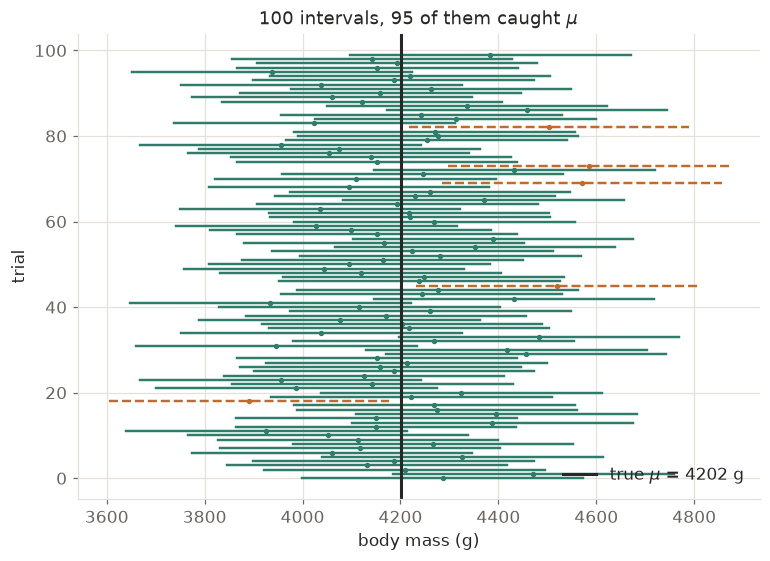

In [4]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for i, row in intervals.iterrows():
    colour = C["accent"] if row["caught"] else C["warn"]
    ax.plot([row["lo"], row["hi"]], [i, i], color=colour, lw=1.6,
            ls="-" if row["caught"] else "--")
    ax.plot(row["mean"], i, "o", color=colour, ms=2.5)

ax.axvline(mu, color=C["ink"], lw=2, label=rf"true $\mu$ = {mu:.0f} g")
ax.set_xlabel("body mass (g)"); ax.set_ylabel("trial")
ax.set_title(rf"100 intervals, {intervals['caught'].sum()} of them caught $\mu$")
ax.legend(loc="lower right")
plt.show()

Every interval is the same width, because the width depends only on $\sigma$, $n$ and the level. What
moves is the centre, and the ones that miss are the samples whose mean happened to land far out.

Nothing went wrong in the misses. They are the price of the method, and they are advertised in
advance: you asked for 95 %, so about 5 in 100 must fail.

In [5]:
# run it properly: 10 000 intervals, so the rate settles
caught = 0
runs = 10_000
half_width = z_star * sigma / np.sqrt(n)
for _ in range(runs):
    m = rng.choice(pop, n, replace=False).mean()
    caught += (m - half_width) <= mu <= (m + half_width)

print(f"capture rate over {runs:,} intervals: {caught / runs:.4f}")
print(f"we asked for {level:.2f}")

capture rate over 10,000 intervals: 0.9584
we asked for 0.95


In [ ]:
# Your turn.
# Repeat the 10 000-interval experiment at the 80% and 99% levels.
# 1. What z* does each need?
# 2. What capture rate do you actually get?
# 3. How much wider is the 99% interval than the 80% one?
# Confidence is bought with width. Put a number on the exchange rate.

for level in [0.80, 0.99]:
    ...

## 8.2 The t distribution

That was a fiction. We used $\sigma$, the population standard deviation, and no researcher has it.
Replace it with the sample standard deviation $s$ and the interval becomes

$$\bar{x} \pm t^{*} \frac{s}{\sqrt{n}}$$

The $t$ distribution has heavier tails than the normal, so $t^{*}$ is larger than $z^{*}$, and the
interval is wider. That extra width is honest. It is the cost of not knowing $\sigma$.

In [6]:
for n_try in [5, 10, 30, 100, 1000]:
    df = n_try - 1
    print(f"n = {n_try:5d}  df = {df:5d}   t* = {stats.t.ppf(0.975, df):.4f}   z* = {stats.norm.ppf(0.975):.4f}")

n =     5  df =     4   t* = 2.7764   z* = 1.9600
n =    10  df =     9   t* = 2.2622   z* = 1.9600
n =    30  df =    29   t* = 2.0452   z* = 1.9600
n =   100  df =    99   t* = 1.9842   z* = 1.9600
n =  1000  df =   999   t* = 1.9623   z* = 1.9600


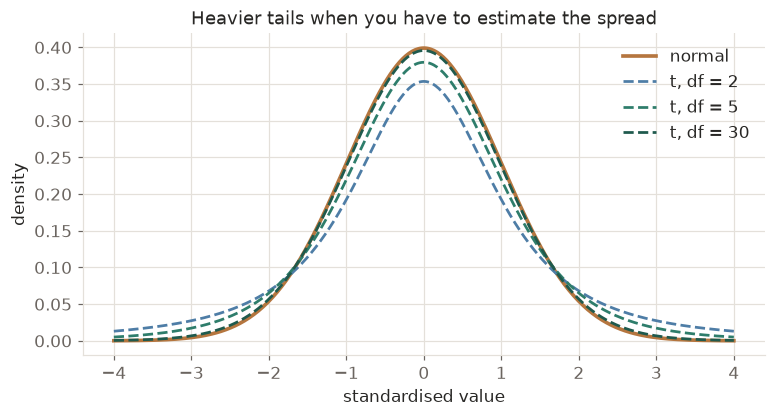

In [7]:
grid = np.linspace(-4, 4, 400)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(grid, stats.norm.pdf(grid), color=C["cat2"], lw=2.4, label="normal")
for df, colour in [(2, C["cat3"]), (5, C["accent"]), (30, C["accent_strong"])]:
    ax.plot(grid, stats.t.pdf(grid, df), color=colour, lw=1.8, ls="--", label=f"t, df = {df}")

ax.set_xlabel("standardised value"); ax.set_ylabel("density")
ax.set_title("Heavier tails when you have to estimate the spread")
ax.legend()
plt.show()

By 30 degrees of freedom the two curves are nearly on top of each other, which is why the old advice
was to switch to $z$ above $n = 30$. With `scipy` in front of you there is no reason to bother.
Always use $t$ when you estimated $s$ from the data.

Here is a real interval from a real sample, computed by hand and then checked against scipy.

In [8]:
sample = rng.choice(pop, 30, replace=False)
n = len(sample)
xbar, s = sample.mean(), sample.std(ddof=1)
t_star = stats.t.ppf(0.975, n - 1)

lo = xbar - t_star * s / np.sqrt(n)
hi = xbar + t_star * s / np.sqrt(n)

print(f"sample mean xbar = {xbar:.1f} g")
print(f"sample sd   s    = {s:.1f} g")
print(f"95% interval     = ({lo:.1f}, {hi:.1f}) g")
print()
print(f"scipy agrees     = {tuple(round(v, 1) for v in stats.t.interval(0.95, n-1, xbar, s/np.sqrt(n)))}")
print(f"the true mu is {mu:.1f} g, which is {'inside' if lo <= mu <= hi else 'outside'} this interval")

sample mean xbar = 4265.8 g
sample sd   s    = 801.8 g
95% interval     = (3966.4, 4565.2) g

scipy agrees     = (np.float64(3966.4), np.float64(4565.2))
the true mu is 4201.8 g, which is inside this interval


In [ ]:
# Your turn.
# Build a 95% t-interval for penguin flipper_length_mm from a sample of 25.
# Then build one from a sample of 100.
# 1. How much narrower is the bigger one?
# 2. Is it narrower by the factor sqrt(100/25) = 2 that the formula predicts? Check.

...

## 8.3 Intervals for proportions

A proportion is a mean of zeros and ones, so the same machinery works with
$SE = \sqrt{\hat{p}(1-\hat{p})/n}$.

The Titanic survival rate is a proportion computed from 891 people, so let us put an interval on it.

In [9]:
titanic = pd.read_csv(DATA / "titanic.csv")
survived = titanic["survived"]

n = len(survived)
p_hat = survived.mean()
se = np.sqrt(p_hat * (1 - p_hat) / n)
z_star = stats.norm.ppf(0.975)

print(f"n = {n},  p-hat = {p_hat:.4f}")
print(f"SE = {se:.4f}")
print(f"95% interval = ({p_hat - z_star*se:.4f}, {p_hat + z_star*se:.4f})")
print(f"margin of error = {z_star * se:.4f}, or about {z_star*se*100:.1f} percentage points")

n = 891,  p-hat = 0.3838
SE = 0.0163
95% interval = (0.3519, 0.4158)
margin of error = 0.0319, or about 3.2 percentage points


That interval only makes sense under a particular reading. If these 891 passengers are the entire
population you care about, the survival rate is 0.3838 exactly and an interval is meaningless. The
interval answers a different question: if this were a sample from some larger process, how precisely
would it pin down that process's rate?

Being clear about which question you are asking is more important than the arithmetic.

The formula also needs a sanity check. It relies on a normal approximation, which needs both
$n\hat{p}$ and $n(1-\hat{p})$ to be at least about 5.

In [10]:
print(f"n * p-hat       = {n * p_hat:.1f}")
print(f"n * (1 - p-hat) = {n * (1 - p_hat):.1f}")
print("both comfortably above 5, so the approximation is safe here")

n * p-hat       = 342.0
n * (1 - p-hat) = 549.0
both comfortably above 5, so the approximation is safe here


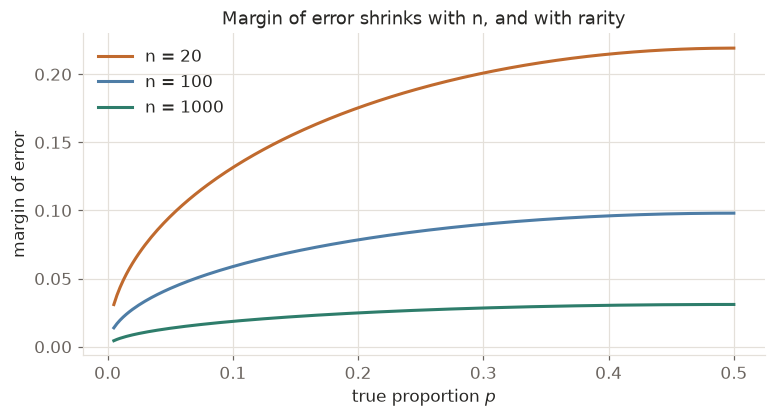

In [11]:
# where it breaks: a rare outcome in a small sample
fig, ax = plt.subplots(figsize=(8, 3.8))

for n_try, colour in [(20, C["warn"]), (100, C["cat3"]), (1000, C["accent"])]:
    ps = np.linspace(0.005, 0.5, 200)
    margins = stats.norm.ppf(0.975) * np.sqrt(ps * (1 - ps) / n_try)
    ax.plot(ps, margins, color=colour, lw=2, label=f"n = {n_try}")

ax.set_xlabel(r"true proportion $p$"); ax.set_ylabel("margin of error")
ax.set_title("Margin of error shrinks with n, and with rarity")
ax.legend()
plt.show()

In [ ]:
# Your turn.
# Compute a 95% interval for the survival rate of women, and another for men.
# 1. Do the two intervals overlap?
# 2. What does non-overlap suggest, and what does it not prove?
# Chapter 10 turns this into a proper test. For now, just look.

...

## Exercises

1. **The level is a promise you can break.** Build 2000 intervals at 90 % using $\sigma$, and 2000
   using $s$ but with $z^{*}$ instead of $t^{*}$ at $n = 5$. Measure both capture rates. The second
   will fall short of 90 %. By how much, and why?

2. **Width against n.** Plot the width of a 95 % t-interval for penguin mass against $n$ from 5 to
   300. Overlay $2 t^{*} s/\sqrt{n}$. Where does the curve stop being worth the extra data?

3. **A polling question.** A poll of 1000 people finds 52 % support. Compute the margin of error.
   Then find the $n$ needed to bring it under 1 point. Compare that with the $n$ most published polls
   actually use.

4. **Small samples and rare events.** Build a 95 % proportion interval for $\hat{p} = 0.02$ with
   $n = 30$. The lower end will be negative, which is impossible. Look up the Wilson interval, apply
   it, and see how it fixes this.

5. **Bootstrap it instead.** Jump ahead to Chapter 16 and build a 95 % interval for penguin body mass
   by resampling rather than by formula. Compare it against the t-interval on the same sample.

## What you should take away

A confidence interval is a statement about a procedure. Ninety-five per cent of the intervals the
method builds will contain the truth, and you never learn which kind yours is. You watched 100 of
them and counted the misses.

Using $t$ rather than $z$ widens the interval to pay for having estimated $s$ from the same data.
And the width falls like $1/\sqrt{n}$, so precision is bought at a rising price, exactly as
Chapter 7 warned.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*